In [2]:
# =============================
# 1) Imports et configuration
# =============================

import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# Pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")

Imports OK


In [3]:
# =====================================
# 2) Chargement des données depuis CSV
# =====================================

CSV_PATH = "../data_folder/cache/BTC-USD.csv"  # <-- A adapter


# Lecture CSV
raw_df = pd.read_csv(CSV_PATH)

raw_df.head()

df = raw_df.copy()


In [4]:
'''# Copie de travail
df = raw_df.copy()

# Conversion en datetime + tri chronologique
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# Option pertinente pour une série temporelle: date comme index
df = df.set_index("date")

# Tri de sécurité sur l'index temporel
df = df.sort_index()

print("Shape du dataset:", df.shape)
print("Période:", df.index.min(), "->", df.index.max())'''

'# Copie de travail\ndf = raw_df.copy()\n\n# Conversion en datetime + tri chronologique\ndf["date"] = pd.to_datetime(df["date"], errors="coerce")\ndf = df.sort_values("date").reset_index(drop=True)\n\n# Option pertinente pour une série temporelle: date comme index\ndf = df.set_index("date")\n\n# Tri de sécurité sur l\'index temporel\ndf = df.sort_index()\n\nprint("Shape du dataset:", df.shape)\nprint("Période:", df.index.min(), "->", df.index.max())'

In [5]:
# ======================================
# 3) Aperçu, types et valeurs manquantes
# ======================================

print("\nAperçu des données:")
display(df.head())

print("\nTypes de colonnes:")
print(df.dtypes)

print("\nValeurs manquantes par colonne:")
print(df.isna().sum())

print("\nStatistiques descriptives:")
display(df.describe().T)


Aperçu des données:


,Date,Open,High,Low,Close,Volume
0,2016-04-24,450.559998,460.145996,448.928009,458.554993,68198400
1,2016-04-25,459.121002,466.619995,453.592010,461.425995,87091800
2,2016-04-26,461.648010,467.964996,461.621002,466.088989,78971904
3,2016-04-27,466.261993,467.079010,444.134003,444.687012,93564896
4,2016-04-28,445.037994,449.550995,436.649994,449.010986,74064704



Types de colonnes:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Valeurs manquantes par colonne:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
Open,3651.0,3.257834e+04,3.258266e+04,4.377930e+02,6.961968e+03,2.016104e+04,5.213789e+04,1.247521e+05
High,3651.0,3.323016e+04,3.312469e+04,4.434270e+02,7.169176e+03,2.046720e+04,5.364853e+04,1.261981e+05
Low,3651.0,3.188724e+04,3.199950e+04,4.366500e+02,6.791375e+03,1.968926e+04,5.089143e+04,1.231960e+05
Close,3651.0,3.259846e+04,3.258645e+04,4.387150e+02,6.969706e+03,2.016072e+04,5.215461e+04,1.247525e+05
Volume,3651.0,2.573173e+10,2.285902e+10,2.851400e+07,6.903790e+09,2.219499e+10,3.709916e+10,3.509679e+11


In [6]:
# =====================
# 4) Création de target
# =====================

horizon = 5  # Nombre de jours dans le futur

# Si close futur > close actuel => target=1, sinon 0
# Note: le dernier(s) point(s) n'a/ont pas de close futur, donc target sera NaN.
df["target"] = (df["Close"].shift(-horizon) > df["Close"]).astype(float)

# On regarde rapidement la distribution de la classe
print("Distribution target (avant dropna final):")
print(df["target"].value_counts(dropna=False))

Distribution target (avant dropna final):
target
1.0    2002
0.0    1649
Name: count, dtype: int64


# Features engineering

In [7]:
# ==============================================
# 5) Fonctions de features techniques (pipeline)
# ==============================================

def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Calcul simple du RSI (Relative Strength Index)."""
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Moyennes mobiles des gains/pertes
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / (avg_loss + 1e-12)  # epsilon pour stabilité numérique
    rsi = 100 - (100 / (1 + rs))
    return rsi


def build_technical_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Transforme un DataFrame OHLCV brut en features techniques.

    Important:
    - on travaille uniquement avec informations présentes au temps t
    - pas d'information future utilisée dans les features
    """
    data = X.copy()

    # S'assure que l'ordre temporel est correct
    data = data.sort_index()

    # MAs de base
    data["ma10"] = data["Close"].rolling(10).mean()
    data["ma30"] = data["Close"].rolling(30).mean()
    data["ma50"] = data["Close"].rolling(50).mean()
    data["ma200"] = data["Close"].rolling(200).mean()

    # 1) pente MA200 (variation relative sur 5 jours)
    data["slope_ma200_5d"] = data["ma200"].pct_change(5)

    # 2) MA50
    data["ma50_level"] = data["ma50"]

    # 3) distance spot / MA30
    data["dist_spot_ma30"] = (data["Close"] / (data["ma30"] + 1e-12)) - 1

    # 4) distance spot / MA50
    data["dist_spot_ma50"] = (data["Close"] / (data["ma50"] + 1e-12)) - 1

    # 5) crossover MA10 / MA200
    data["ma10_200_crossover"] = (data["ma10"] / (data["ma200"] + 1e-12)) - 1

    # 6) RSI
    data["rsi14"] = compute_rsi(data["Close"], window=14)

    # 7) volatility ratio 30 / 200
    daily_ret = data["Close"].pct_change()
    vol30 = daily_ret.rolling(30).std()
    vol200 = daily_ret.rolling(200).std()
    data["vol_ratio_30_200"] = vol30 / (vol200 + 1e-12)

    # Features additionnelles
    data["ret_1d"] = daily_ret
    data["mom_5d"] = data["Close"].pct_change(5)
    data["mom_10d"] = data["Close"].pct_change(10)
    data["mom_20d"] = data["Close"].pct_change(20)
    data["daily_range"] = (data["High"] - data["Low"]) / (data["Close"] + 1e-12)
    data["dist_spot_ma200"] = (data["Close"] / (data["ma200"] + 1e-12)) - 1
    data["slope_ma50_5d"] = data["ma50"].pct_change(5)
    data["volume_change_1d"] = data["Volume"].pct_change(1)
    data["rolling_vol_20"] = daily_ret.rolling(20).std()

    # Colonnes finales utilisées par le modèle
    feature_cols = [
        "slope_ma200_5d",
        "ma50_level",
        "dist_spot_ma30",
        "dist_spot_ma50",
        "ma10_200_crossover",
        "rsi14",
        "vol_ratio_30_200",
        "ret_1d",
        "mom_5d",
        "mom_10d",
        "mom_20d",
        "daily_range",
        "dist_spot_ma200",
        "slope_ma50_5d",
        "volume_change_1d",
        "rolling_vol_20",
    ]

    return data[feature_cols]

## 5) Préparation `X` / `y` + split chronologique

In [17]:
df.head()

,Date,Open,High,Low,Close,Volume,target
0,2016-04-12,422.842987,427.277008,422.842987,425.190002,70728800,1.0
1,2016-04-13,425.631989,426.657990,422.915985,423.734009,69060400,1.0
2,2016-04-14,423.934998,425.371002,423.013000,424.282013,45281000,1.0
3,2016-04-15,424.427002,429.928009,424.427002,429.713013,54801500,1.0
4,2016-04-16,429.575012,432.625000,428.984009,430.571991,39392800,1.0


In [8]:
# ==================================================
# 6) Construction de X/y et split temporel explicite
# ==================================================

# Entrées brutes pour le transformer
raw_feature_cols = ["Open", "High", "Low", "Close", "Volume"]
X_raw = df[raw_feature_cols].copy()
y_raw = df["target"].copy()

# Calcul temporaire des features pour trouver les lignes exploitables
X_feat_tmp = build_technical_features(X_raw)

# On conserve uniquement les lignes où features + target sont définies
valid_mask = X_feat_tmp.notna().all(axis=1) & y_raw.notna()
X_raw_clean = X_raw.loc[valid_mask].copy()
y_clean = y_raw.loc[valid_mask].astype(int).copy()

print("Nombre d'observations valides:", len(X_raw_clean))
print("Distribution target finale:")
print(y_clean.value_counts(normalize=True).rename("ratio"))

# Split chronologique (80% train / 20% test)
split_ratio = 0.8
split_idx = int(len(X_raw_clean) * split_ratio)

X_train = X_raw_clean.iloc[:split_idx].copy()
X_test = X_raw_clean.iloc[split_idx:].copy()
y_train = y_clean.iloc[:split_idx].copy()
y_test = y_clean.iloc[split_idx:].copy()

print("\nShapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nPériodes:")
print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test :", X_test.index.min(), "->", X_test.index.max())

Nombre d'observations valides: 3447
Distribution target finale:
target
1    0.544822
0    0.455178
Name: ratio, dtype: float64

Shapes:
X_train: (2757, 5) | y_train: (2757,)
X_test : (690, 5) | y_test : (690,)

Périodes:
Train: 204 -> 2960
Test : 2961 -> 3650


# Date pivot

In [9]:
index_pivot = df.index[split_idx]
print("\nDate de pivot (train/test):", index_pivot)



Date de pivot (train/test): 2757


In [10]:
date_pivot = df.Date[split_idx]
print("\nDate de pivot (train/test):", date_pivot)


Date de pivot (train/test): 2023-11-11


In [19]:
# ====================================================
# 7) Construction du pipeline complet avec XGBoost
# ====================================================

feature_transformer = FunctionTransformer(build_technical_features, validate=False)

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,      # L1
    reg_lambda=1.5,     # L2
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Nombre de composantes PCA paramétrable
N_PCA_COMPONENTS = 0.95

pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_transformer),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        #("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", xgb_clf),
    ]
)

print(pipeline)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function build_technical_features at 0x7fd216dcf880>)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=

In [20]:
# ======================
# 8) Entraînement modèle
# ======================

pipeline.fit(X_train, y_train)

# Prédictions classes
y_pred = pipeline.predict(X_test)

# Prédictions probabilités (classe positive)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Entraînement terminé.")

Entraînement terminé.


Accuracy : 0.4928
Precision: 0.5244
Recall   : 0.3269
F1-score : 0.4027

Classification report:

              precision    recall  f1-score   support

           0     0.4774    0.6748    0.5592       329
           1     0.5244    0.3269    0.4027       361

    accuracy                         0.4928       690
   macro avg     0.5009    0.5008    0.4810       690
weighted avg     0.5020    0.4928    0.4773       690



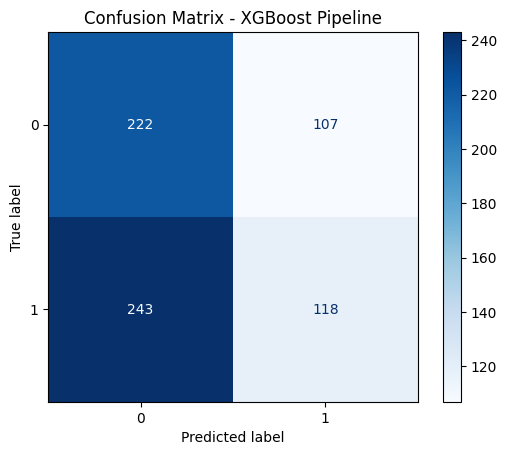


Interprétation rapide:
- Accuracy donne la performance globale.
- Precision mesure la fiabilité des signaux haussiers prédits.
- Recall mesure la capacité à capturer les hausses réelles.
- F1 équilibre precision et recall, utile en cas de classes déséquilibrées.


In [16]:
# ========================
# 9) Métriques et analyse
# ========================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost Pipeline")
plt.show()

print("\nInterprétation rapide:")
print("- Accuracy donne la performance globale.")
print("- Precision mesure la fiabilité des signaux haussiers prédits.")
print("- Recall mesure la capacité à capturer les hausses réelles.")
print("- F1 équilibre precision et recall, utile en cas de classes déséquilibrées.")

In [21]:
a=1

In [ ]:
# =========================================
# 10) Tuning optionnel avec TimeSeriesSplit
# =========================================

RUN_TUNING = False  # Mettre à True pour lancer la recherche

if RUN_TUNING:
    tscv = TimeSeriesSplit(n_splits=4)

    param_distributions = {
        #"pca__n_components": [5, 8, 10, 12],
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
        "model__learning_rate": [0.01, 0.03, 0.05],
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="f1",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    random_search.fit(X_train, y_train)
    print("Meilleurs paramètres:")
    print(random_search.best_params_)
    print("Meilleur score CV (f1):", random_search.best_score_)

    # On remplace le pipeline de base par le meilleur pipeline trouvé
    pipeline = random_search.best_estimator_

    # Ré-entraînement implicite déjà fait par RandomizedSearchCV sur tous les folds,
    # mais on recalcule les prédictions sur test pour comparer proprement.
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\nMetrics test après tuning:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
else:
    print("Tuning non lancé (RUN_TUNING=False).")

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Meilleurs paramètres:
{'model__subsample': 0.7, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
Meilleur score CV (f1): 0.5900858832309709

Metrics test après tuning:
Accuracy : 0.4957
Precision: 0.5208
Recall   : 0.4515
F1-score : 0.4837


In [38]:
# ==========================
# 11) Sauvegarde du pipeline
# ==========================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "xgb_pipeline.pkl")

with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Pipeline sauvegardé dans: {model_path}")

Pipeline sauvegardé dans: ../models/xgb_pipeline.pkl


In [ ]:
# Load the model from the pickle file
model_path = os.path.join(ROOT_PATH, 'models', 'best_model.pkl')
with open(model_path, 'rb') as file:
     model = pickle.load(file)

In [37]:
df.tail()

,Date,Open,High,Low,Close,Volume,target
3652,2026-04-12,73056.046875,73154.031250,70540.570312,70753.406250,29882740487,0.0
3653,2026-04-13,70757.617188,74896.312500,70588.523438,74484.640625,52278211554,0.0
3654,2026-04-14,74478.398438,76061.757812,73877.203125,74181.609375,53540826530,0.0
3655,2026-04-15,74182.023438,75409.273438,73549.203125,74805.078125,38090174312,0.0
3656,2026-04-16,74810.875000,75506.570312,73346.265625,75152.132812,41312783855,0.0


In [11]:
# =========================================================
# 7bis) Pipeline avec modèle linéaire de classification
# =========================================================

feature_transformer = FunctionTransformer(build_technical_features, validate=False)

linear_clf = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=2000,
    #class_weight="balanced"  # utile si classes un peu déséquilibrées
)

linear_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_transformer),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("model", linear_clf),
    ]
)

print("Pipeline linéaire :")
print(linear_pipeline)

Pipeline linéaire :
Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function build_technical_features at 0x795ac1d1e520>)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])


In [12]:
# ==========================================
# 8bis) Entraînement du modèle linéaire
# ==========================================

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)
y_proba_linear = linear_pipeline.predict_proba(X_test)[:, 1]

print("Entraînement du pipeline linéaire terminé.")

Entraînement du pipeline linéaire terminé.



===== Résultats Logistic Regression =====
Accuracy : 0.4761
Precision: 0.4884
Recall   : 0.1167
F1-score : 0.1883

Classification report:

              precision    recall  f1-score   support

           0     0.4744    0.8671    0.6132       331
           1     0.4884    0.1167    0.1883       360

    accuracy                         0.4761       691
   macro avg     0.4814    0.4919    0.4008       691
weighted avg     0.4817    0.4761    0.3919       691



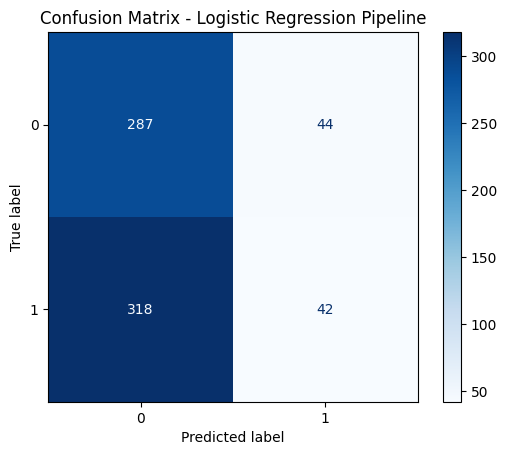

In [13]:
# ==========================================
# 9bis) Métriques du modèle linéaire
# ==========================================

acc_linear = accuracy_score(y_test, y_pred_linear)
prec_linear = precision_score(y_test, y_pred_linear, zero_division=0)
rec_linear = recall_score(y_test, y_pred_linear, zero_division=0)
f1_linear = f1_score(y_test, y_pred_linear, zero_division=0)

print("\n===== Résultats Logistic Regression =====")
print(f"Accuracy : {acc_linear:.4f}")
print(f"Precision: {prec_linear:.4f}")
print(f"Recall   : {rec_linear:.4f}")
print(f"F1-score : {f1_linear:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_linear, digits=4))

cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression Pipeline")
plt.show()

Fitting 4 folds for each of 20 candidates, totalling 80 fits

===== Meilleurs paramètres Logistic Regression =====
{'pca__n_components': 0.9, 'model__solver': 'saga', 'model__penalty': 'l1', 'model__class_weight': None, 'model__C': np.float64(0.003359818286283781)}
Meilleur score CV (f1): 0.6940182495528912

===== Metrics test après tuning =====
Accuracy : 0.5210
Precision: 0.5210
Recall   : 1.0000
F1-score : 0.6851

Classification report après tuning:

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       331
           1     0.5210    1.0000    0.6851       360

    accuracy                         0.5210       691
   macro avg     0.2605    0.5000    0.3425       691
weighted avg     0.2714    0.5210    0.3569       691



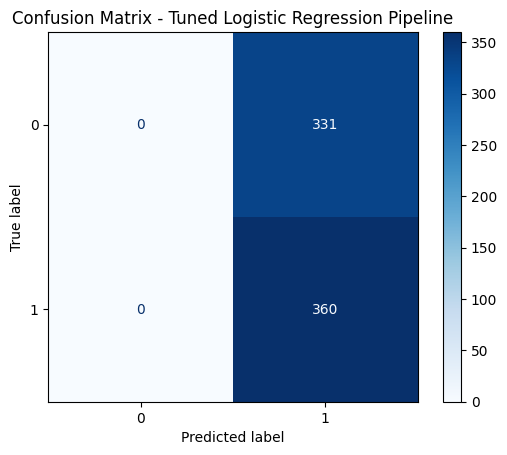

In [14]:
# ===================================================
# 10bis) Tuning du modèle linéaire avec TimeSeriesCV
# ===================================================

RUN_LINEAR_TUNING = True

if RUN_LINEAR_TUNING:
    tscv = TimeSeriesSplit(n_splits=4)

    param_distributions_linear = {
        "pca__n_components": [0.80, 0.90, 0.95, 0.99],
        "model__C": np.logspace(-3, 2, 20),
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear", "saga"],
        "model__class_weight": [None, "balanced"],
    }

    random_search_linear = RandomizedSearchCV(
        estimator=linear_pipeline,
        param_distributions=param_distributions_linear,
        n_iter=20,
        scoring="f1",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    random_search_linear.fit(X_train, y_train)

    print("\n===== Meilleurs paramètres Logistic Regression =====")
    print(random_search_linear.best_params_)
    print("Meilleur score CV (f1):", random_search_linear.best_score_)

    best_linear_pipeline = random_search_linear.best_estimator_

    y_pred_linear = best_linear_pipeline.predict(X_test)
    y_proba_linear = best_linear_pipeline.predict_proba(X_test)[:, 1]

    acc_linear = accuracy_score(y_test, y_pred_linear)
    prec_linear = precision_score(y_test, y_pred_linear, zero_division=0)
    rec_linear = recall_score(y_test, y_pred_linear, zero_division=0)
    f1_linear = f1_score(y_test, y_pred_linear, zero_division=0)

    print("\n===== Metrics test après tuning =====")
    print(f"Accuracy : {acc_linear:.4f}")
    print(f"Precision: {prec_linear:.4f}")
    print(f"Recall   : {rec_linear:.4f}")
    print(f"F1-score : {f1_linear:.4f}")

    print("\nClassification report après tuning:\n")
    print(classification_report(y_test, y_pred_linear, digits=4))

    cm_linear = confusion_matrix(y_test, y_pred_linear)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix - Tuned Logistic Regression Pipeline")
    plt.show()

else:
    print("Tuning linéaire non lancé (RUN_LINEAR_TUNING=False).")
    best_linear_pipeline = linear_pipeline

In [15]:
# ==========================================
# 11bis) Sauvegarde du pipeline linéaire
# ==========================================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

linear_model_path = os.path.join(model_dir, "last_linear_pipeline.pkl")

with open(linear_model_path, "wb") as f:
    pickle.dump(best_linear_pipeline, f)

print(f"Pipeline linéaire sauvegardé dans : {linear_model_path}")

Pipeline linéaire sauvegardé dans : ../models/last_linear_pipeline.pkl


In [ ]:
comparison_df = pd.DataFrame({
    "model": ["xgboost", "logistic_regression"],
    "accuracy": [acc, acc_linear],
    "precision": [prec, prec_linear],
    "recall": [rec, rec_linear],
    "f1_score": [f1, f1_linear],
})

display(comparison_df)